Применим методы машинного обучения к задаче

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


Feature engineering 


In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

df['Is_New_Customer'] = (df['tenure'] <= 6).astype(int)
df['Chaser_Flag'] = ((df['Contract'] == 'Month-to-month') & (df['PaymentMethod'] == 'Electronic check')).astype(int)

df['Avg_Monthly_Charge'] = df['TotalCharges'] / (df['tenure'] + 1) 

df['Has_Security'] = ((df['OnlineSecurity'] == 'Yes') | (df['OnlineBackup'] == 'Yes') | 
                      (df['DeviceProtection'] == 'Yes') | (df['TechSupport'] == 'Yes')).astype(int)
df['Has_Streaming'] = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')).astype(int)

df_model = df.drop(columns=['customerID', 'tenure', 'TotalCharges'])

categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
                    'PaperlessBilling', 'PaymentMethod']

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

services_list = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['Num_Services'] = (df[services_list] == 'Yes').sum(axis=1)
df['Is_New_Customer'] = (df['tenure'] <= 6).astype(int)
df['Chaser_Flag'] = ((df['Contract'] == 'Month-to-month') & 
                     (df['PaymentMethod'] == 'Electronic check')).astype(int)
df['Has_Security'] = (df['OnlineSecurity'] == 'Yes').astype(int)
df['Has_Streaming'] = ((df['StreamingTV'] == 'Yes') | 
                       (df['StreamingMovies'] == 'Yes')).astype(int)
df['Avg_Monthly_Charge'] = df['TotalCharges'] / (df['tenure'] + 1)

X = df.drop(columns=['customerID', 'Churn'])  
y = df['Churn']


num_cols = ['MonthlyCharges', 'Avg_Monthly_Charge', 'Num_Services', 
            'Is_New_Customer', 'Chaser_Flag', 'Has_Security', 'Has_Streaming']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

num_cols = ['MonthlyCharges', 'Avg_Monthly_Charge', 'Num_Services', 'Is_New_Customer', 
            'Chaser_Flag', 'Has_Security', 'Has_Streaming']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Размер тренировочной выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер тренировочной выборки: (5634, 25)
Размер тестовой выборки: (1409, 25)


обучение базовых моделей

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred_lr = pipeline.predict(X_test)
y_prob_lr = pipeline.predict_proba(X_test)[:, 1]


тестировка базовой модели

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.8417


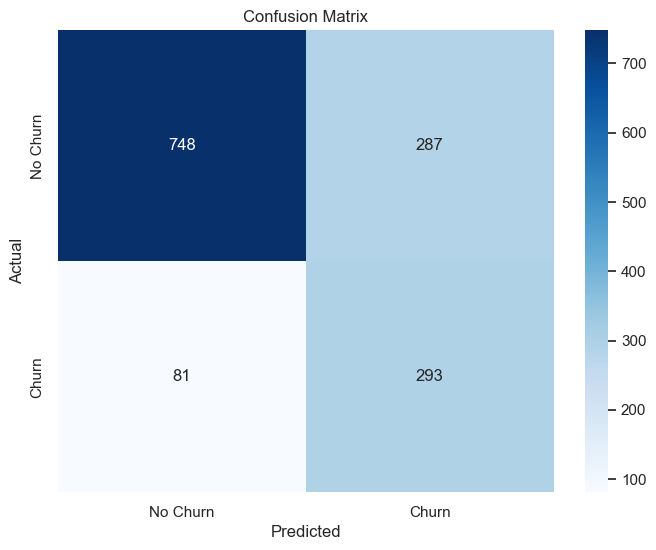

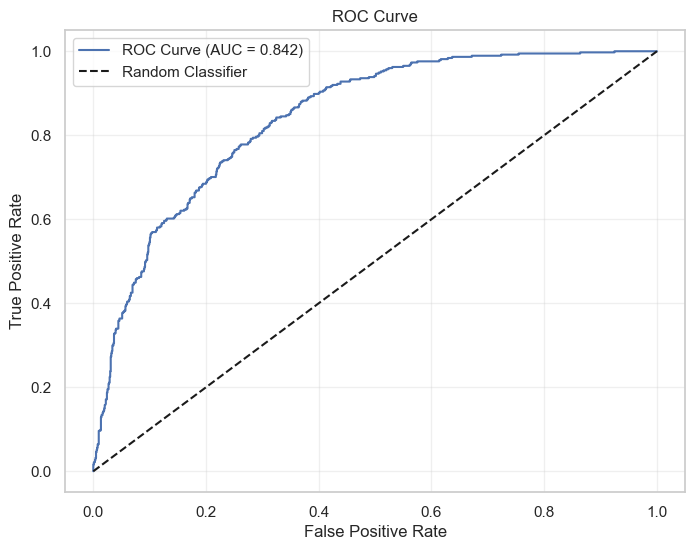

In [58]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

к линейной модели добавим ансамблевые древесные алгоритмы

In [59]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report)


df_copy = df.copy()

label_encoders = {}
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
                    'MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract', 
                    'PaperlessBilling', 'PaymentMethod']

for col in categorical_cols:
    le = LabelEncoder()
    df_copy[col] = le.fit_transform(df_copy[col])
    label_encoders[col] = le

X = df_copy.drop(['customerID', 'Churn'], axis=1)
y = df_copy['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
}

print("\n=== ОБУЧЕНИЕ МОДЕЛЕЙ ===\n")
trained_models = {}

for name, model in models.items():
    print(f"Обучение {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    train_score = model.score(X_train, y_train)
    print(f"  Accuracy на тренировочных данных: {train_score:.4f}\n")

print("Все модели успешно обучены!")

Размер обучающей выборки: (5634, 25)
Размер тестовой выборки: (1409, 25)

=== ОБУЧЕНИЕ МОДЕЛЕЙ ===

Обучение Decision Tree...
  Accuracy на тренировочных данных: 0.8009

Обучение Random Forest...
  Accuracy на тренировочных данных: 0.8669

Обучение Gradient Boosting...
  Accuracy на тренировочных данных: 0.8774

Все модели успешно обучены!


тестировка моделей

=== Метрики ансамблевых моделей ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.7722,0.5575,0.6872,0.6156,0.8378
Gradient Boosting,0.7942,0.6419,0.5080,0.5672,0.8355


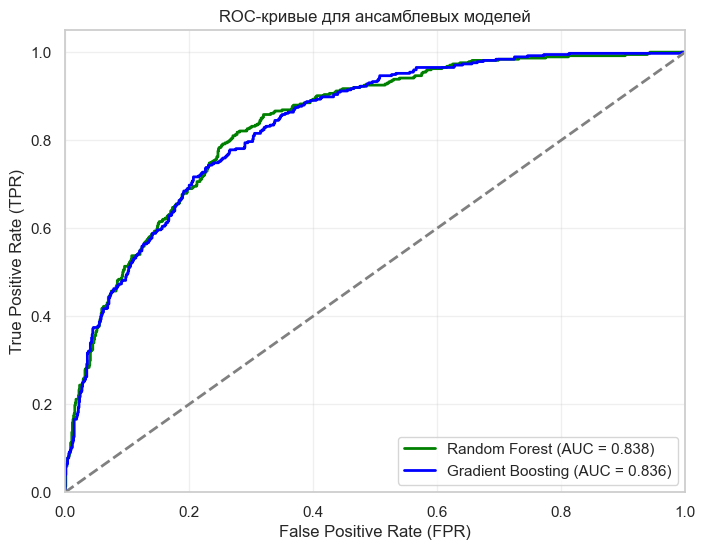

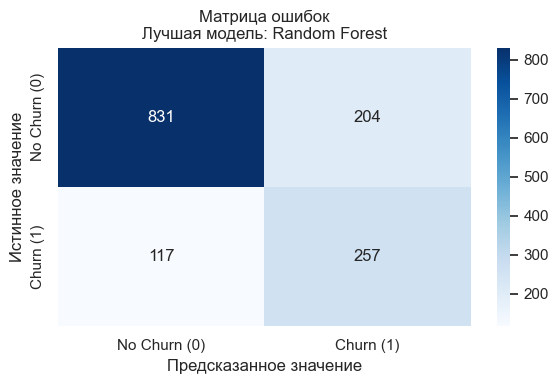

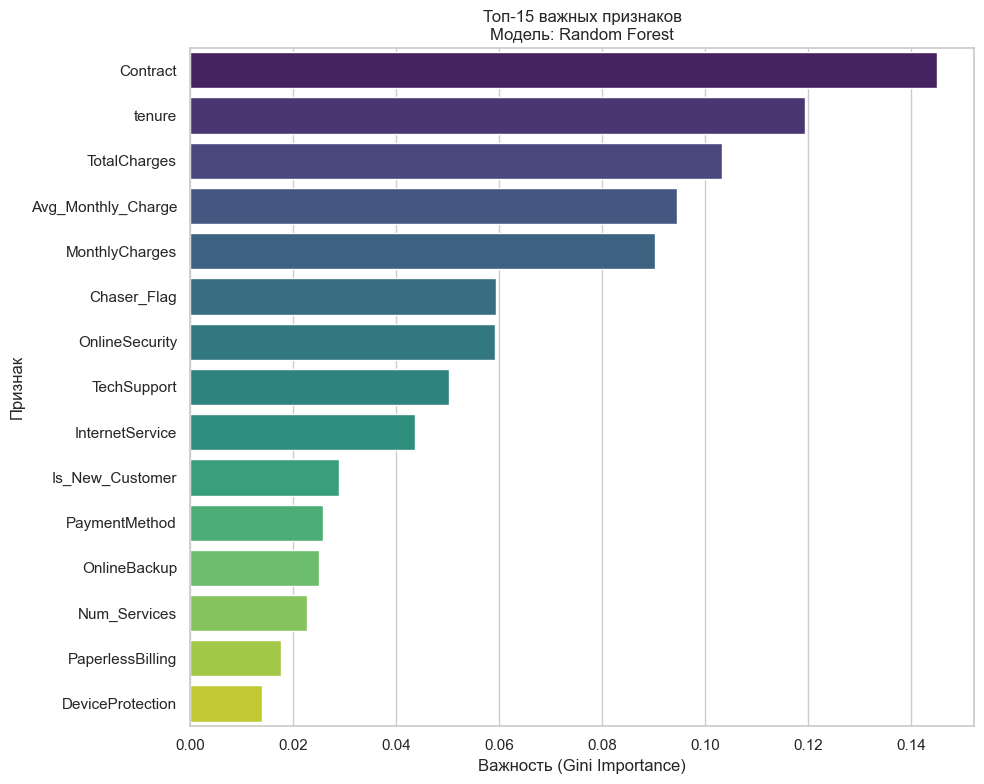

In [60]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier




scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, 
        random_state=42, 
        class_weight='balanced', 
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        max_depth=5, 
        learning_rate=0.1, 
        random_state=42
    )
}

results = {}
probas_dict = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    probas_dict[name] = y_pred_proba
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }

metrics_df = pd.DataFrame(results).T
metrics_df = metrics_df.applymap(lambda x: f"{x:.4f}") 
print("=== Метрики ансамблевых моделей ===")
display(metrics_df)


plt.figure(figsize=(8, 6))
colors = ['green', 'blue']

for (name, y_proba), color in zip(probas_dict.items(), colors):
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривые для ансамблевых моделей')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


best_model_name = max(results, key=lambda x: float(results[x]['ROC-AUC']))
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn (0)', 'Churn (1)'], 
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.title(f'Матрица ошибок\nЛучшая модель: {best_model_name}')
plt.ylabel('Истинное значение')
plt.xlabel('Предсказанное значение')
plt.tight_layout()
plt.show()


if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
    
    top_n = 15
    plt.figure(figsize=(10, 8))
    sns.barplot(x=feat_imp.values[:top_n], y=feat_imp.index[:top_n], palette='viridis')
    plt.title(f'Топ-{top_n} важных признаков\nМодель: {best_model_name}')
    plt.xlabel('Важность (Gini Importance)')
    plt.ylabel('Признак')
    plt.tight_layout()
    plt.show()
else:
    print("Выбранная модель не поддерживает извлечение feature_importances_")

разработаем алгоритм подбора рекомендаций для изменений в клиентском сервисе для повышения удержания клиентов: реализуем алгоритм подбора изменений в услугах, дабы подстроиться по вероятные ожидания клиента.

начнем с feature engineering, будем оперировать дискретными вариантами изменения сервисов, то есть скидки и остальное переводится в определенный дискретный набор

In [61]:
# Комбинация ключевых факторов риска
df['Risk_Score'] = (
    (df['Contract'] == 'Month-to-month').astype(int) * 3 +
    (df['PaymentMethod'] == 'Electronic check').astype(int) * 2 +
    (df['InternetService'] == 'Fiber optic').astype(int) * 2 +
    (df['tenure'] <= 6).astype(int) * 4 +
    (df['MonthlyCharges'] > 70).astype(int) * 1
)
# Сколько клиент платит за каждую услугу
df['Service_Value_Ratio'] = df['MonthlyCharges'] / (df['Num_Services'] + 1)

# Индекс стабильности контракта
contract_map = {'Month-to-month': 1, 'One year': 2, 'Two year': 3}
df['Contract_Stability'] = df['Contract'].map(contract_map)

# Удобство оплаты (автоматические vs ручные)
df['Payment_Auto'] = df['PaymentMethod'].isin([
    'Bank transfer (automatic)', 
    'Credit card (automatic)'
]).astype(int)

# Fiber optic + Month-to-month = максимальный риск
df['Fiber_Risk'] = (
    (df['InternetService'] == 'Fiber optic') & 
    (df['Contract'] == 'Month-to-month')
).astype(int)

# Категоризация клиентов по типу услуг
def categorize_bundle(row):
    security_services = sum([
        row['OnlineSecurity'] == 'Yes',
        row['OnlineBackup'] == 'Yes',
        row['DeviceProtection'] == 'Yes',
        row['TechSupport'] == 'Yes'
    ])
    streaming_services = sum([
        row['StreamingTV'] == 'Yes',
        row['StreamingMovies'] == 'Yes'
    ])
    
    if security_services >= 2 and streaming_services >= 1:
        return 'Full_Bundle'
    elif security_services >= 2:
        return 'Security_Focused'
    elif streaming_services >= 1:
        return 'Entertainment_Focused'
    else:
        return 'Basic'

df['Bundle_Type'] = df.apply(categorize_bundle, axis=1)

# Для новых клиентов - насколько быстро они "растут"
df['Tenure_Momentum'] = df['tenure'] / (df['Num_Services'] + 1)

# Клиенты с необычно высокими charges для их tenure
df['Avg_Charge_Expected'] = df['TotalCharges'] / (df['tenure'] + 1)
df['Charge_Anomaly'] = (
    abs(df['MonthlyCharges'] - df['Avg_Charge_Expected']) > 20
).astype(int)

In [62]:
from itertools import product

def generate_service_recommendations(customer_row, model, label_encoders, 
                                    feature_columns, max_recommendations=3, 
                                    min_improvement=0.05):
    """
    Генерирует рекомендации по изменению сервисов для конкретного клиента.
    
    Args:
        customer_row: pd.Series - данные клиента (оригинальные, со строками)
        model: обученная модель (Random Forest / Gradient Boosting)
        label_encoders: dict - LabelEncoder'ы из Cell 49
        feature_columns: list - список колонок X (в том же порядке, что при обучении)
        max_recommendations: максимальное количество рекомендаций
        min_improvement: минимальное улучшение вероятности (порог)
    """
    
    def encode_customer(row_series):
        """Применяет LabelEncoder'ы к категориальным колонкам и выравнивает порядок признаков."""
        row = row_series.copy()
        for col, le in label_encoders.items():
            if col in row.index and isinstance(row[col], str):
                # если значение не встречалось в обучении — оставляем как есть (не должно случиться)
                if row[col] in le.classes_:
                    row[col] = le.transform([row[col]])[0]
        # Оставляем только нужные фичи в правильном порядке, числовые — как есть
        return row[feature_columns].to_frame().T
    
    # Базовая вероятность оттока
    X_customer = encode_customer(customer_row)
    base_proba = model.predict_proba(X_customer)[0][1]
    
    if base_proba < 0.3:
        return []
    
    recommendations = []
    
    services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']
    
    # 1. Рекомендации по добавлению сервисов
    for service in services:
        if customer_row.get(service, 'No') == 'No':
            modified_customer = customer_row.copy()
            modified_customer[service] = 'Yes'
            X_modified = encode_customer(modified_customer)
            new_proba = model.predict_proba(X_modified)[0][1]
            improvement = base_proba - new_proba
            
            if improvement >= min_improvement:
                recommendations.append({
                    'type': 'add_service',
                    'change': f'Добавить {service}',
                    'improvement': improvement,
                    'new_churn_proba': new_proba,
                    'reason': f'Клиенты с {service} имеют на {improvement*100:.1f}% меньший риск оттока'
                })
    
    # 2. Рекомендации по изменению контракта
    if customer_row.get('Contract') == 'Month-to-month':
        for contract_type in ['One year', 'Two year']:
            modified_customer = customer_row.copy()
            modified_customer['Contract'] = contract_type
            X_modified = encode_customer(modified_customer)
            new_proba = model.predict_proba(X_modified)[0][1]
            improvement = base_proba - new_proba
            
            if improvement >= min_improvement:
                recommendations.append({
                    'type': 'change_contract',
                    'change': f'Изменить контракт на {contract_type}',
                    'improvement': improvement,
                    'new_churn_proba': new_proba,
                    'reason': f'Переход на {contract_type} контракт снижает риск оттока на {improvement*100:.1f}%'
                })
    
    # 3. Рекомендации по изменению способа оплаты
    if customer_row.get('PaymentMethod') == 'Electronic check':
        for payment_type in ['Bank transfer (automatic)', 'Credit card (automatic)']:
            modified_customer = customer_row.copy()
            modified_customer['PaymentMethod'] = payment_type
            X_modified = encode_customer(modified_customer)
            new_proba = model.predict_proba(X_modified)[0][1]
            improvement = base_proba - new_proba
            
            if improvement >= min_improvement:
                recommendations.append({
                    'type': 'change_payment',
                    'change': f'Изменить способ оплаты на {payment_type}',
                    'improvement': improvement,
                    'new_churn_proba': new_proba,
                    'reason': f'Автоматические платежи снижают риск оттока на {improvement*100:.1f}%'
                })
    
    # 4. Комбинированные рекомендации (топ-2 изменения)
    if len(recommendations) >= 2:
        top_changes = sorted(recommendations, key=lambda x: x['improvement'], reverse=True)[:2]
        
        modified_customer = customer_row.copy()
        for rec in top_changes:
            if rec['type'] == 'add_service':
                service_name = rec['change'].replace('Добавить ', '')
                modified_customer[service_name] = 'Yes'
            elif rec['type'] == 'change_contract':
                contract_type = rec['change'].replace('Изменить контракт на ', '')
                modified_customer['Contract'] = contract_type
            elif rec['type'] == 'change_payment':
                payment_type = rec['change'].replace('Изменить способ оплаты на ', '')
                modified_customer['PaymentMethod'] = payment_type
        
        X_modified = encode_customer(modified_customer)
        combined_proba = model.predict_proba(X_modified)[0][1]
        combined_improvement = base_proba - combined_proba
        
        if combined_improvement >= min_improvement:
            recommendations.append({
                'type': 'combined',
                'change': ' + '.join([r['change'] for r in top_changes]),
                'improvement': combined_improvement,
                'new_churn_proba': combined_proba,
                'reason': f'Комбинация изменений дает максимальное снижение риска на {combined_improvement*100:.1f}%'
            })
    
    recommendations = sorted(recommendations, key=lambda x: x['improvement'], reverse=True)
    return recommendations[:max_recommendations]

print("✓ Функция для генерации рекомендаций создана")

✓ Функция для генерации рекомендаций создана


In [63]:
def explain_recommendation(customer_row, recommendation, model, 
                           feature_importances, feature_names):
    """Объясняет рекомендацию через важность признаков."""
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importances
    }).sort_values('importance', ascending=False)
    
    top_features = importance_df.head(5)
    relevant_features = []
    
    if recommendation['type'] == 'add_service':
        service_name = recommendation['change'].replace('Добавить ', '')
        for _, row in top_features.iterrows():
            if service_name.lower() in row['feature'].lower():
                relevant_features.append({
                    'feature': row['feature'],
                    'importance': row['importance'],
                    'current_value': customer_row.get(service_name, 'No')
                })
    elif recommendation['type'] == 'change_contract':
        for _, row in top_features.iterrows():
            if 'contract' in row['feature'].lower():
                relevant_features.append({
                    'feature': row['feature'],
                    'importance': row['importance'],
                    'current_value': customer_row.get('Contract', 'Unknown')
                })
    elif recommendation['type'] == 'change_payment':
        for _, row in top_features.iterrows():
            if 'payment' in row['feature'].lower():
                relevant_features.append({
                    'feature': row['feature'],
                    'importance': row['importance'],
                    'current_value': customer_row.get('PaymentMethod', 'Unknown')
                })
    
    return {
        'recommendation': recommendation['change'],
        'expected_improvement': f"{recommendation['improvement']*100:.1f}%",
        'new_churn_probability': f"{recommendation['new_churn_proba']*100:.1f}%",
        'reason': recommendation['reason'],
        'key_factors': relevant_features if relevant_features else [],
        'top_important_features': top_features.to_dict('records')
    }

print("✓ Функция для объяснения рекомендаций создана")

✓ Функция для объяснения рекомендаций создана


In [64]:
# Определяем лучшую модель
best_model_name = max(results, key=lambda x: float(results[x]['ROC-AUC']))
best_model = models[best_model_name]

print(f"Используем модель: {best_model_name}")
print(f"ROC-AUC: {results[best_model_name]['ROC-AUC']}")

# Feature importance
feature_importances = best_model.feature_importances_
feature_names = X.columns.tolist()   # ← ключевое исправление

print(f"\nРазмер feature_names: {len(feature_names)}, "
      f"размер feature_importances: {len(feature_importances)}")

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)
print("\nТоп-10 важных признаков:")
print(importance_df.head(10))

# Находим клиентов с высоким риском оттока
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
high_risk_mask = y_pred_proba > 0.6
high_risk_indices = X_test.index[high_risk_mask]   # ← работаем с индексами df
high_risk_probas = y_pred_proba[high_risk_mask]

print(f"\nНайдено {len(high_risk_indices)} клиентов с высоким риском оттока (>60%)")

# Генерируем рекомендации
recommendations_all = []

for row_index, churn_proba in zip(high_risk_indices[:10], high_risk_probas[:10]):
    customer_original = df.loc[row_index]        # ← берём из df (все признаки на месте)
    customer_id = customer_original['customerID']
    
    recs = generate_service_recommendations(
        customer_original,
        best_model,
        label_encoders,      # ← из Cell 49
        X.columns.tolist(),
        max_recommendations=3,
        min_improvement=0.05
    )
    
    if recs:
        best_rec = recs[0]
        explanation = explain_recommendation(
            customer_original,
            best_rec,
            best_model,
            feature_importances,
            feature_names
        )
        
        recommendations_all.append({
            'customer_id': customer_id,
            'current_churn_proba': churn_proba,
            'recommendation': explanation
        })

print(f"\nСгенерировано рекомендаций: {len(recommendations_all)}")

Используем модель: Random Forest
ROC-AUC: 0.837845203957736

Размер feature_names: 25, размер feature_importances: 25

Топ-10 важных признаков:
               feature  importance
14            Contract    0.145002
4               tenure    0.119417
18        TotalCharges    0.103328
21  Avg_Monthly_Charge    0.094632
17      MonthlyCharges    0.090365
20         Chaser_Flag    0.059440
8       OnlineSecurity    0.059230
11         TechSupport    0.050316
7      InternetService    0.043726
19     Is_New_Customer    0.028804

Найдено 367 клиентов с высоким риском оттока (>60%)

Сгенерировано рекомендаций: 6


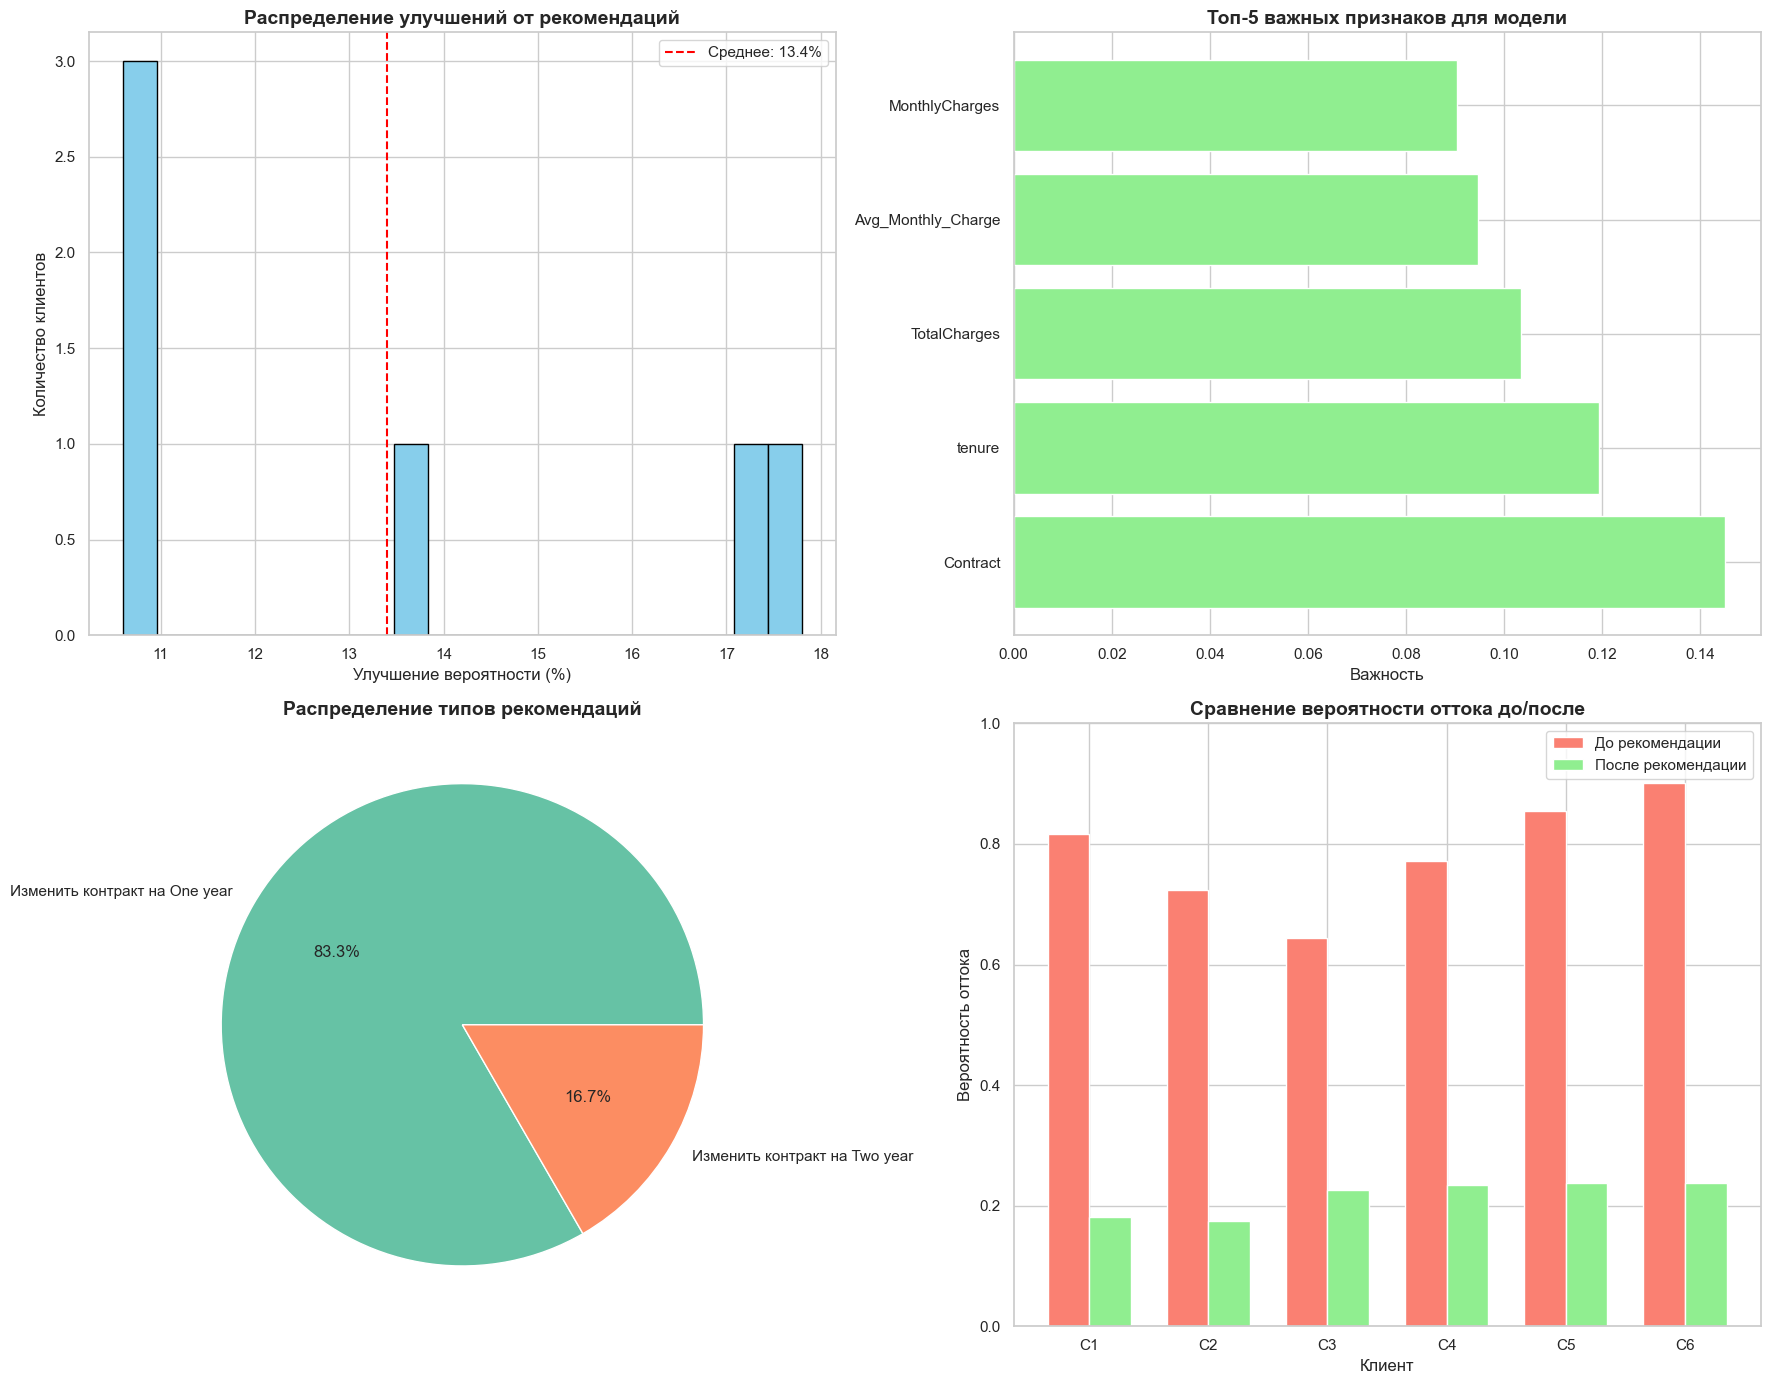


✓ Визуализация завершена


In [65]:
# Cell 4: Визуализация рекомендаций
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Распределение улучшений
improvements = [rec['recommendation']['expected_improvement'] for rec in recommendations_all]
improvements_numeric = [float(imp.strip('%')) for imp in improvements]

axes[0, 0].hist(improvements_numeric, bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Улучшение вероятности (%)', fontsize=12)
axes[0, 0].set_ylabel('Количество клиентов', fontsize=12)
axes[0, 0].set_title('Распределение улучшений от рекомендаций', fontsize=14, fontweight='bold')
axes[0, 0].axvline(np.mean(improvements_numeric), color='red', linestyle='--', 
                   label=f'Среднее: {np.mean(improvements_numeric):.1f}%')
axes[0, 0].legend()

# 2. Топ-5 важных признаков
top_features = importance_df.head(5)
axes[0, 1].barh(top_features['feature'], top_features['importance'], color='lightgreen')
axes[0, 1].set_xlabel('Важность', fontsize=12)
axes[0, 1].set_title('Топ-5 важных признаков для модели', fontsize=14, fontweight='bold')

# 3. Типы рекомендаций
rec_types = [rec['recommendation']['recommendation'] for rec in recommendations_all]
type_counts = pd.Series(rec_types).value_counts()
axes[1, 0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
               colors=sns.color_palette('Set2'))
axes[1, 0].set_title('Распределение типов рекомендаций', fontsize=14, fontweight='bold')

# 4. До vs После
before_proba = [rec['current_churn_proba'] for rec in recommendations_all]
after_proba = [float(rec['recommendation']['new_churn_probability'].strip('%'))/100 
               for rec in recommendations_all]

x = np.arange(len(before_proba))
width = 0.35

axes[1, 1].bar(x - width/2, before_proba, width, label='До рекомендации', color='salmon')
axes[1, 1].bar(x + width/2, after_proba, width, label='После рекомендации', color='lightgreen')
axes[1, 1].set_xlabel('Клиент', fontsize=12)
axes[1, 1].set_ylabel('Вероятность оттока', fontsize=12)
axes[1, 1].set_title('Сравнение вероятности оттока до/после', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels([f"C{i+1}" for i in x])
axes[1, 1].legend()
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\n✓ Визуализация завершена")

In [66]:
# Cell 5: Детальный отчет по рекомендациям
print("="*80)
print("ДЕТАЛЬНЫЙ ОТЧЕТ ПО РЕКОМЕНДАЦИЯМ ДЛЯ КЛИЕНТОВ С ВЫСОКИМ РИСКОМ ОТТОКА")
print("="*80)

for i, rec_data in enumerate(recommendations_all, 1):
    print(f"\n{'='*80}")
    print(f"КЛИЕНТ #{i}: {rec_data['customer_id']}")
    print(f"{'='*80}")
    print(f"Текущая вероятность оттока: {rec_data['current_churn_proba']*100:.1f}%")
    print(f"\nРЕКОМЕНДАЦИЯ:")
    print(f"  Действие: {rec_data['recommendation']['recommendation']}")
    print(f"  Ожидаемое улучшение: {rec_data['recommendation']['expected_improvement']}")
    print(f"  Новая вероятность оттока: {rec_data['recommendation']['new_churn_probability']}")
    print(f"\n  Обоснование: {rec_data['recommendation']['reason']}")
    
    if rec_data['recommendation']['key_factors']:
        print(f"\n  Ключевые факторы:")
        for factor in rec_data['recommendation']['key_factors']:
            print(f"    - {factor['feature']}: важность {factor['importance']:.3f}, "
                  f"текущее значение: {factor['current_value']}")
    
    print(f"\n  Топ-5 важных признаков модели:")
    for j, feat in enumerate(rec_data['recommendation']['top_important_features'][:5], 1):
        print(f"    {j}. {feat['feature']}: {feat['importance']:.3f}")

print(f"\n{'='*80}")
print(f"ИТОГО:")
print(f"  Обработано клиентов: {len(recommendations_all)}")
print(f"  Среднее улучшение: {np.mean(improvements_numeric):.1f}%")
print(f"  Максимальное улучшение: {max(improvements_numeric):.1f}%")
print(f"{'='*80}")

ДЕТАЛЬНЫЙ ОТЧЕТ ПО РЕКОМЕНДАЦИЯМ ДЛЯ КЛИЕНТОВ С ВЫСОКИМ РИСКОМ ОТТОКА

КЛИЕНТ #1: 2754-SDJRD
Текущая вероятность оттока: 81.7%

РЕКОМЕНДАЦИЯ:
  Действие: Изменить контракт на One year
  Ожидаемое улучшение: 17.8%
  Новая вероятность оттока: 18.1%

  Обоснование: Переход на One year контракт снижает риск оттока на 17.8%

  Ключевые факторы:
    - Contract: важность 0.145, текущее значение: Month-to-month

  Топ-5 важных признаков модели:
    1. Contract: 0.145
    2. tenure: 0.119
    3. TotalCharges: 0.103
    4. Avg_Monthly_Charge: 0.095
    5. MonthlyCharges: 0.090

КЛИЕНТ #2: 4686-UXDML
Текущая вероятность оттока: 72.4%

РЕКОМЕНДАЦИЯ:
  Действие: Изменить контракт на Two year
  Ожидаемое улучшение: 17.3%
  Новая вероятность оттока: 17.4%

  Обоснование: Переход на Two year контракт снижает риск оттока на 17.3%

  Ключевые факторы:
    - Contract: важность 0.145, текущее значение: Month-to-month

  Топ-5 важных признаков модели:
    1. Contract: 0.145
    2. tenure: 0.119
    3. Tota